# RuVector Signal Geometry

Purpose: visualize the Milestone 9 RuVector research equivalents for subcarrier partitioning, attention-gated spectrograms, BVP aggregation, Fresnel geometry, TDoA triangulation, and compressed temporal histories.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The cells are deterministic and do not require radio hardware, captured packets, or a completed `ruview.ruvector` implementation.

Fixture / simulated source: inline NumPy fixtures create synthetic subcarrier sensitivity scores, Doppler spectrogram energy, per-subcarrier STFT rows, wavelength/amplitude observations, access-point timing measurements, and breathing/heartbeat histories. Guarded imports probe `ruview.ruvector`; local fallback helpers keep the notebook runnable while Milestone 9 code workers are still in progress.

In [1]:
import math

import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError('Install the research extra with: uv sync --extra research') from exc

try:
    import ruview.ruvector as ruvector_api
except Exception as exc:
    ruvector_api = None
    RUVECTOR_IMPORT_ERROR = exc
else:
    RUVECTOR_IMPORT_ERROR = None

try:
    from ruview.ruvector import signal as ruvector_signal
except Exception as exc:
    ruvector_signal = getattr(ruvector_api, 'signal', None) if ruvector_api is not None else None
    RUVECTOR_SIGNAL_IMPORT_ERROR = exc
else:
    RUVECTOR_SIGNAL_IMPORT_ERROR = None

try:
    from ruview.ruvector import mat as ruvector_mat
except Exception as exc:
    ruvector_mat = getattr(ruvector_api, 'mat', None) if ruvector_api is not None else None
    RUVECTOR_MAT_IMPORT_ERROR = exc
else:
    RUVECTOR_MAT_IMPORT_ERROR = None

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

API_IMPORT_STATUS = {
    'ruview.ruvector': 'available' if ruvector_api is not None else 'fallback',
    'ruview.ruvector.signal': 'available' if ruvector_signal is not None else 'fallback',
    'ruview.ruvector.mat': 'available' if ruvector_mat is not None else 'fallback',
}
print(API_IMPORT_STATUS)


{'ruview.ruvector': 'available', 'ruview.ruvector.signal': 'fallback', 'ruview.ruvector.mat': 'fallback'}


In [2]:
def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)
    weights = np.exp(shifted)
    total = np.sum(weights)
    if total <= 1e-12:
        return np.ones_like(logits) / max(1, logits.size)
    return weights / total


def _try_signal(name, *args):
    fn = getattr(ruvector_signal, name, None)
    if callable(fn):
        try:
            return fn(*args), 'api'
        except Exception:
            pass
    return None, 'fallback'


def _try_mat(name, *args):
    fn = getattr(ruvector_mat, name, None)
    if callable(fn):
        try:
            return fn(*args), 'api'
        except Exception:
            pass
    return None, 'fallback'


def partition_subcarriers(sensitivity):
    arr = np.asarray(sensitivity, dtype=float)
    result, source = _try_signal('partition_subcarriers', arr)
    if result is None:
        result, source = _try_signal('mincut_subcarrier_partition', arr.tolist())
    if result is not None:
        sensitive, insensitive = result
        return np.asarray(sensitive, dtype=int), np.asarray(insensitive, dtype=int), source

    if arr.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int), source
    threshold = np.median(arr)
    sensitive = np.flatnonzero(arr >= threshold)
    insensitive = np.flatnonzero(arr < threshold)
    if sensitive.size == 0 or insensitive.size == 0:
        order = np.argsort(arr)
        split = max(1, arr.size // 2)
        insensitive = order[:split]
        sensitive = order[split:]
    if arr[sensitive].mean() < arr[insensitive].mean():
        sensitive, insensitive = insensitive, sensitive
    return np.sort(sensitive), np.sort(insensitive), source


def importance_weights(sensitivity, sensitive_idx):
    arr = np.asarray(sensitivity, dtype=float)
    max_score = max(float(np.max(arr)), 1e-9)
    weights = np.full(arr.shape, 0.5, dtype=float)
    weights[sensitive_idx] = 1.0 + np.clip(arr[sensitive_idx] / max_score, 0.0, 1.0)
    return weights


def gate_spectrogram(spectrogram, lambda_gate=0.35):
    spec = np.asarray(spectrogram, dtype=float)
    result, source = _try_signal('gate_spectrogram', spec.ravel().tolist(), spec.shape[0], spec.shape[1], float(lambda_gate))
    if result is not None:
        return np.asarray(result, dtype=float).reshape(spec.shape), source

    frame_energy = np.sqrt(np.mean(spec * spec, axis=0))
    low, high = np.quantile(frame_energy, [0.15, 0.90])
    motion_score = np.clip((frame_energy - low) / max(high - low, 1e-9), 0.0, 1.0)
    kernel = np.array([0.2, 0.6, 0.2])
    motion_score = np.convolve(motion_score, kernel, mode='same')
    gate = np.clip(0.45 + (1.0 + lambda_gate) * motion_score, 0.25, 1.45)
    return spec * gate[None, :], source


def attention_weighted_bvp(stft_rows, sensitivity):
    rows = np.asarray(stft_rows, dtype=float)
    scores = np.asarray(sensitivity, dtype=float)
    result, source = _try_signal('attention_weighted_bvp', rows.tolist(), scores.tolist(), rows.shape[1])
    if result is not None:
        return np.asarray(result, dtype=float), source, None

    query = np.average(rows, axis=0, weights=np.maximum(scores, 1e-6))
    logits = rows @ query / math.sqrt(rows.shape[1]) + np.log1p(np.maximum(scores, 0.0))
    weights = softmax(logits)
    return weights @ rows, source, weights


def solve_fresnel_geometry(observations, d_total):
    result, source = _try_signal('solve_fresnel_geometry', observations, float(d_total))
    if result is not None:
        d1, d2 = result
        return (float(d1), float(d2)), source

    obs = np.asarray(observations, dtype=float)
    wavelengths = obs[:, 0]
    amplitudes = obs[:, 1]
    lambda_ref = np.mean(wavelengths)
    path_asymmetry = np.mean(amplitudes * wavelengths / lambda_ref)
    path_asymmetry = float(np.clip(path_asymmetry, -0.96, 0.96))
    d1 = 0.5 * d_total * (1.0 + path_asymmetry)
    d2 = d_total - d1
    return (d1, d2), source


def solve_tdoa_triangulation(measurements, ap_positions, room_xy, step=0.035):
    result, source = _try_mat('solve_tdoa_triangulation', measurements, ap_positions)
    if result is None:
        result, source = _try_mat('solve_triangulation', measurements, ap_positions)
    if result is not None:
        return np.asarray(result, dtype=float), source, np.nan

    c_mps = 3.0e8
    aps = np.asarray(ap_positions, dtype=float)
    xs = np.arange(0.0, room_xy[0] + step, step)
    ys = np.arange(0.0, room_xy[1] + step, step)
    xx, yy = np.meshgrid(xs, ys)
    loss = np.zeros_like(xx)
    for i, j, tdoa_s in measurements:
        ri = np.sqrt((xx - aps[i, 0]) ** 2 + (yy - aps[i, 1]) ** 2)
        rj = np.sqrt((xx - aps[j, 0]) ** 2 + (yy - aps[j, 1]) ** 2)
        residual_m = ri - rj - c_mps * float(tdoa_s)
        loss += residual_m * residual_m
    best = np.unravel_index(np.argmin(loss), loss.shape)
    estimate = np.array([xx[best], yy[best]])
    rms_residual = float(np.sqrt(loss[best] / max(1, len(measurements))))
    return estimate, source, rms_residual


def tiered_quantize(values, hot_frames=28, warm_frames=130):
    values = np.asarray(values, dtype=float)
    n_frames, n_features = values.shape
    age = n_frames - 1 - np.arange(n_frames)
    bits = np.where(age < hot_frames, 8, np.where(age < warm_frames, 6, 3))
    lo, hi = np.quantile(values, [0.01, 0.99])
    span = max(float(hi - lo), 1e-9)
    clipped = np.clip(values, lo, hi)
    reconstructed = np.empty_like(values)
    for bit_depth in np.unique(bits):
        rows = bits == bit_depth
        levels = 2 ** int(bit_depth) - 1
        q = np.rint((clipped[rows] - lo) / span * levels)
        reconstructed[rows] = q / levels * span + lo
    raw_bytes = values.size * 4.0
    compressed_bytes = float(np.sum(bits) * n_features / 8.0)
    return reconstructed, bits, raw_bytes, compressed_bytes


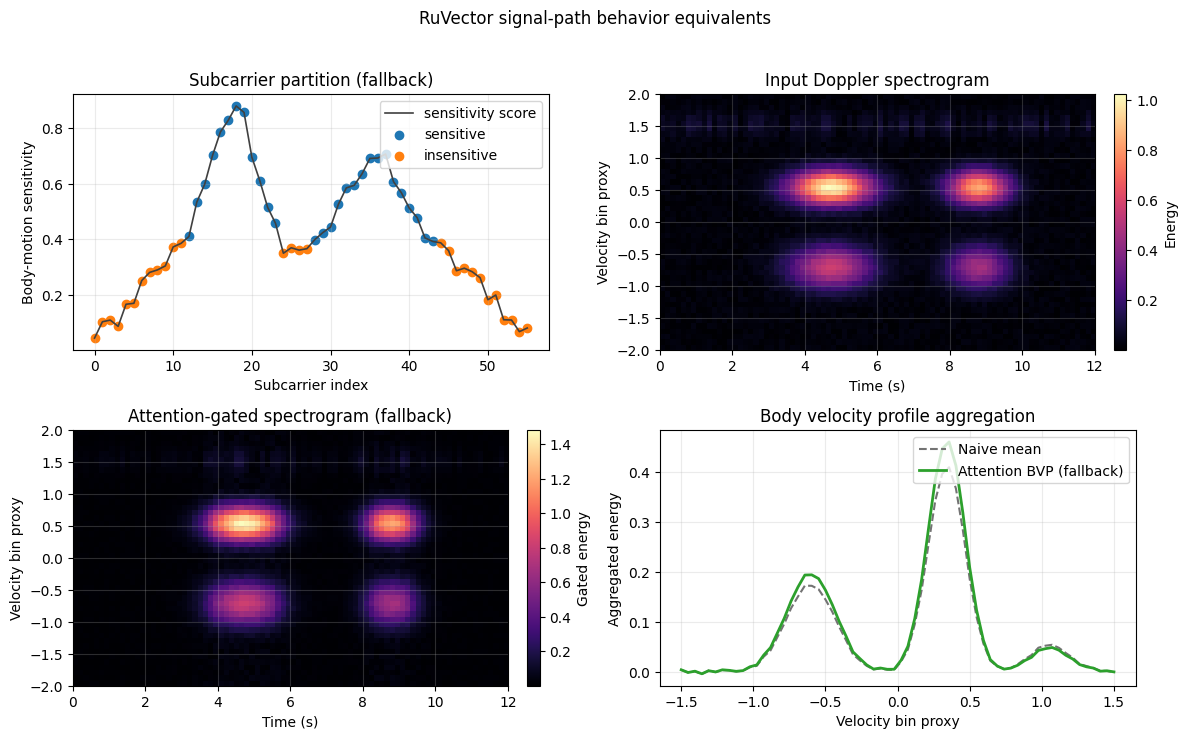

In [3]:
rng = np.random.default_rng(1909)
n_subcarriers = 56
subcarrier_idx = np.arange(n_subcarriers)
subcarrier_axis = np.linspace(-1.0, 1.0, n_subcarriers)

sensitivity = 0.18 + 0.10 * np.sin(3.0 * np.pi * (subcarrier_axis + 0.15))
sensitivity += 0.78 * np.exp(-((subcarrier_axis + 0.35) / 0.18) ** 2)
sensitivity += 0.58 * np.exp(-((subcarrier_axis - 0.32) / 0.23) ** 2)
sensitivity += rng.normal(0.0, 0.025, n_subcarriers)
sensitivity = np.clip(sensitivity, 0.01, None)

sensitive_idx, insensitive_idx, partition_source = partition_subcarriers(sensitivity)
subcarrier_weights = importance_weights(sensitivity, sensitive_idx)

n_freq, n_time = 48, 84
freq_axis = np.linspace(-2.0, 2.0, n_freq)
time_axis = np.linspace(0.0, 12.0, n_time)
motion_envelope = np.exp(-((time_axis - 4.7) / 1.15) ** 2) + 0.82 * np.exp(-((time_axis - 8.8) / 0.85) ** 2)
body_band = np.exp(-((freq_axis[:, None] - 0.55) / 0.28) ** 2) + 0.55 * np.exp(-((freq_axis[:, None] + 0.72) / 0.34) ** 2)
spectrogram = 0.035 * rng.random((n_freq, n_time)) + body_band * motion_envelope[None, :]
spectrogram += 0.10 * np.exp(-((freq_axis[:, None] - 1.55) / 0.20) ** 2) * rng.random((1, n_time))
gated_spectrogram, gate_source = gate_spectrogram(spectrogram)

velocity_axis = np.linspace(-1.5, 1.5, 64)
velocity_profile = np.exp(-((velocity_axis - 0.34) / 0.18) ** 2) + 0.42 * np.exp(-((velocity_axis + 0.60) / 0.24) ** 2)
stft_rows = sensitivity[:, None] * velocity_profile[None, :]
stft_rows += 0.10 * (1.0 - sensitivity[:, None] / sensitivity.max()) * np.exp(-((velocity_axis[None, :] - 1.05) / 0.20) ** 2)
stft_rows += rng.normal(0.0, 0.015, stft_rows.shape)
bvp_attention, bvp_source, bvp_weights = attention_weighted_bvp(stft_rows, sensitivity)
bvp_naive = np.mean(stft_rows, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))
axes[0, 0].plot(subcarrier_idx, sensitivity, color='0.25', linewidth=1.2, label='sensitivity score')
axes[0, 0].scatter(sensitive_idx, sensitivity[sensitive_idx], color='#1f77b4', label='sensitive')
axes[0, 0].scatter(insensitive_idx, sensitivity[insensitive_idx], color='#ff7f0e', label='insensitive')
axes[0, 0].set_title(f'Subcarrier partition ({partition_source})')
axes[0, 0].set_xlabel('Subcarrier index')
axes[0, 0].set_ylabel('Body-motion sensitivity')
axes[0, 0].legend(loc='upper right')

before = axes[0, 1].imshow(spectrogram, origin='lower', aspect='auto', extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]], cmap='magma')
axes[0, 1].set_title('Input Doppler spectrogram')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Velocity bin proxy')
fig.colorbar(before, ax=axes[0, 1], fraction=0.046, pad=0.04, label='Energy')

after = axes[1, 0].imshow(gated_spectrogram, origin='lower', aspect='auto', extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]], cmap='magma')
axes[1, 0].set_title(f'Attention-gated spectrogram ({gate_source})')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Velocity bin proxy')
fig.colorbar(after, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Gated energy')

axes[1, 1].plot(velocity_axis, bvp_naive, color='0.45', linestyle='--', label='Naive mean')
axes[1, 1].plot(velocity_axis, bvp_attention, color='#2ca02c', linewidth=2.0, label=f'Attention BVP ({bvp_source})')
axes[1, 1].set_title('Body velocity profile aggregation')
axes[1, 1].set_xlabel('Velocity bin proxy')
axes[1, 1].set_ylabel('Aggregated energy')
axes[1, 1].legend(loc='upper right')

fig.suptitle('RuVector signal-path behavior equivalents', y=1.02)
fig.tight_layout()


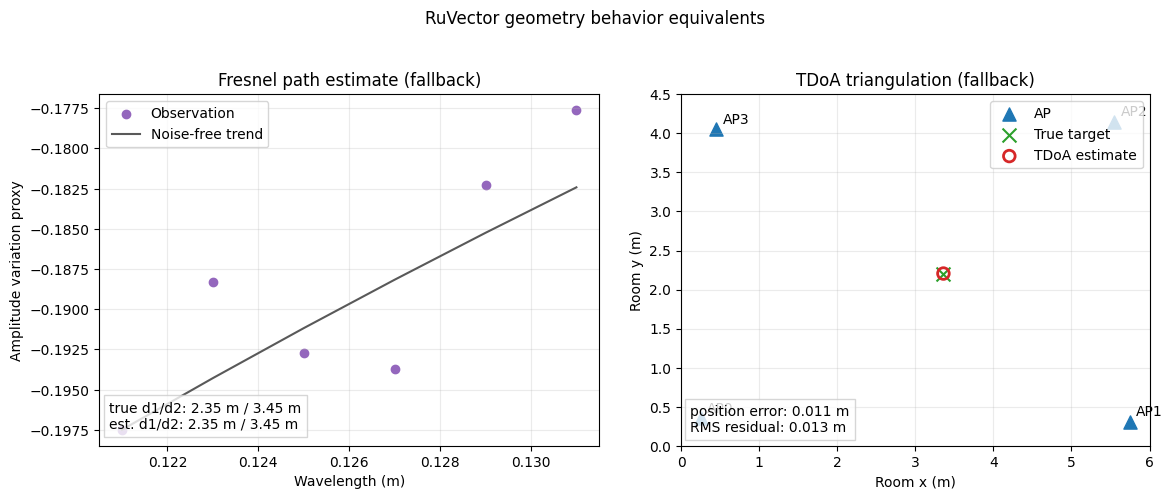

In [4]:
d_total = 5.8
d1_true = 2.35
d2_true = d_total - d1_true
wavelengths_m = np.array([0.121, 0.123, 0.125, 0.127, 0.129, 0.131])
lambda_ref = float(np.mean(wavelengths_m))
path_asymmetry = (d1_true - d2_true) / d_total
amplitudes = path_asymmetry * (lambda_ref / wavelengths_m) + 0.006 * np.sin(np.arange(wavelengths_m.size) * 1.7)
fresnel_observations = [(float(w), float(a)) for w, a in zip(wavelengths_m, amplitudes)]
(d1_est, d2_est), fresnel_source = solve_fresnel_geometry(fresnel_observations, d_total)

room_xy = (6.0, 4.5)
ap_positions = np.array([
    [0.25, 0.35],
    [5.75, 0.30],
    [5.55, 4.15],
    [0.45, 4.05],
], dtype=float)
target_xy = np.array([3.35, 2.20], dtype=float)
distances = np.sqrt(np.sum((ap_positions - target_xy[None, :]) ** 2, axis=1))
c_mps = 3.0e8
tdoa_measurements = []
for pair in [(1, 0), (2, 0), (3, 0), (2, 1), (3, 1)]:
    i, j = pair
    tdoa_measurements.append((i, j, float((distances[i] - distances[j]) / c_mps)))
tdoa_estimate, tdoa_source, tdoa_residual = solve_tdoa_triangulation(tdoa_measurements, ap_positions.tolist(), room_xy)
tdoa_error = float(np.linalg.norm(tdoa_estimate - target_xy))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(wavelengths_m, amplitudes, color='#9467bd', label='Observation')
axes[0].plot(wavelengths_m, path_asymmetry * (lambda_ref / wavelengths_m), color='0.35', label='Noise-free trend')
axes[0].set_title(f'Fresnel path estimate ({fresnel_source})')
axes[0].set_xlabel('Wavelength (m)')
axes[0].set_ylabel('Amplitude variation proxy')
axes[0].legend(loc='best')
axes[0].text(0.02, 0.05, f'true d1/d2: {d1_true:.2f} m / {d2_true:.2f} m\nest. d1/d2: {d1_est:.2f} m / {d2_est:.2f} m', transform=axes[0].transAxes, bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': '0.8'})

axes[1].scatter(ap_positions[:, 0], ap_positions[:, 1], marker='^', s=90, color='#1f77b4', label='AP')
for idx, (x_pos, y_pos) in enumerate(ap_positions):
    axes[1].text(x_pos + 0.08, y_pos + 0.08, f'AP{idx}')
axes[1].scatter([target_xy[0]], [target_xy[1]], marker='x', s=100, color='#2ca02c', label='True target')
axes[1].scatter([tdoa_estimate[0]], [tdoa_estimate[1]], marker='o', s=70, facecolor='none', edgecolor='#d62728', linewidth=2, label='TDoA estimate')
axes[1].set_xlim(0.0, room_xy[0])
axes[1].set_ylim(0.0, room_xy[1])
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title(f'TDoA triangulation ({tdoa_source})')
axes[1].set_xlabel('Room x (m)')
axes[1].set_ylabel('Room y (m)')
axes[1].legend(loc='upper right')
axes[1].text(0.02, 0.04, f'position error: {tdoa_error:.3f} m\nRMS residual: {tdoa_residual:.3f} m', transform=axes[1].transAxes, bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': '0.8'})

fig.suptitle('RuVector geometry behavior equivalents', y=1.03)
fig.tight_layout()


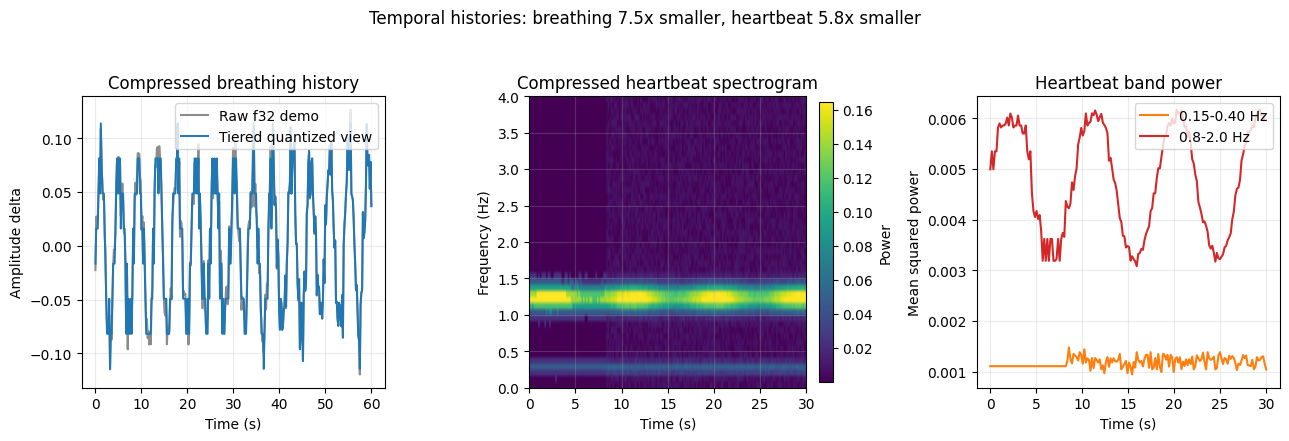

In [5]:
history_time = np.linspace(0.0, 60.0, 360)
breathing_hz = 0.24
breathing_history = 0.08 * np.sin(2.0 * np.pi * breathing_hz * history_time)[:, None] * (0.55 + sensitivity[None, :])
breathing_history += 0.018 * rng.normal(size=breathing_history.shape)
breathing_recon, breathing_bits, breathing_raw, breathing_compressed = tiered_quantize(breathing_history)

heartbeat_freqs = np.linspace(0.0, 4.0, 48)
heartbeat_times = np.linspace(0.0, 30.0, 180)
cardiac_center_hz = 1.22
heartbeat_spectrogram = 0.010 * rng.random((heartbeat_times.size, heartbeat_freqs.size))
heartbeat_spectrogram += 0.15 * np.exp(-((heartbeat_freqs[None, :] - cardiac_center_hz) / 0.18) ** 2) * (1.0 + 0.18 * np.sin(2.0 * np.pi * heartbeat_times[:, None] / 9.0))
heartbeat_spectrogram += 0.045 * np.exp(-((heartbeat_freqs[None, :] - breathing_hz) / 0.09) ** 2)
heartbeat_recon, heartbeat_bits, heartbeat_raw, heartbeat_compressed = tiered_quantize(heartbeat_spectrogram)

cardiac_band = (heartbeat_freqs >= 0.8) & (heartbeat_freqs <= 2.0)
resp_band = (heartbeat_freqs >= 0.15) & (heartbeat_freqs <= 0.40)
cardiac_power = np.mean(heartbeat_recon[:, cardiac_band] ** 2, axis=1)
resp_power = np.mean(heartbeat_recon[:, resp_band] ** 2, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
subcarrier_to_show = int(sensitive_idx[len(sensitive_idx) // 2])
axes[0].plot(history_time, breathing_history[:, subcarrier_to_show], color='0.55', label='Raw f32 demo')
axes[0].plot(history_time, breathing_recon[:, subcarrier_to_show], color='#1f77b4', linewidth=1.4, label='Tiered quantized view')
axes[0].set_title('Compressed breathing history')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude delta')
axes[0].legend(loc='upper right')

img = axes[1].imshow(heartbeat_recon.T, origin='lower', aspect='auto', extent=[heartbeat_times[0], heartbeat_times[-1], heartbeat_freqs[0], heartbeat_freqs[-1]], cmap='viridis')
axes[1].set_title('Compressed heartbeat spectrogram')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
fig.colorbar(img, ax=axes[1], fraction=0.046, pad=0.04, label='Power')

axes[2].plot(heartbeat_times, resp_power, color='#ff7f0e', label='0.15-0.40 Hz')
axes[2].plot(heartbeat_times, cardiac_power, color='#d62728', label='0.8-2.0 Hz')
axes[2].set_title('Heartbeat band power')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Mean squared power')
axes[2].legend(loc='upper right')

breathing_ratio = breathing_raw / breathing_compressed
heartbeat_ratio = heartbeat_raw / heartbeat_compressed
fig.suptitle(f'Temporal histories: breathing {breathing_ratio:.1f}x smaller, heartbeat {heartbeat_ratio:.1f}x smaller', y=1.04)
fig.tight_layout()


Expected interpretation: the sensitive subcarrier group should land on the synthetic body-motion lobes, the gated spectrogram should reduce quiet/noisy time frames while preserving motion bursts, and the attention BVP should emphasize the intended velocity peak more clearly than the naive mean. The Fresnel panel should recover a plausible `d1 + d2` split close to the known baseline, the TDoA panel should place the estimate near the true room target, and temporal compression should keep recent breathing/heartbeat structure visible while lowering the demo byte budget.

Limitations: this is a deterministic visual fixture, not a validated RF propagation model, calibrated Fresnel solver, emergency localization system, or temporal-tensor parity test. The local fallbacks approximate the published Rust integration behavior with readable NumPy helpers instead of dependency-internal RuVector min-cut, attention, sparse Neumann solver, or compression internals. Treat thresholds, path estimates, localization error, and compression ratios as notebook diagnostics only.